<a href="https://colab.research.google.com/github/LorenzoBioinfo/import-bioinformatics/blob/main/notebooks/SequenceAnalysis_Biopython.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sequence Analysis with Biopython


**Chapter:** 01 — Bioinformatics Foundations  
**Level:** Beginner  
**Estimated time:** ~2 hours


In questo notebook, vedremo alcune funzioni di basi per l'analisi delle sequenze utilizzando Biopython.

## Cos'è Biopython?

BioPython è la libreria Python standard per la bioinformatica. Non è un singolo tool ma una collezione di moduli indipendenti che coprono: parsing di formati biologici (FASTA, PDB, GenBank, mmCIF), accesso a database (NCBI, PDB, UniProt), analisi di sequenze e strutture, allineamento, filogenesi e molto altro. Ogni modulo può essere usato indipendentemente.

La filosofia di BioPython è diversa da quella di NumPy o PyTorch: invece di operazioni vettoriali veloci su array, BioPython fornisce oggetti biologicamente significativi (Sequence, Structure, Alignment) con metodi che riflettono il vocabolario della biologia. Ad esempio, una *Seq*, come vedremo nel notebook, non è solo una stringa di caratteri.

---
## Cosa impareremo

- Leggere e scrivere file FASTA con Biopython

- Calcolare il contenuto GC si una sequenza singola e di più sequenze in contemporanea (il nostro dataset)

- Tascrizione e Traduzione del DNA

- Trovare motivi e open reading frames (ORFs)

- Scaricare sequenze da NCBI con Entrez

- Creare visualizzazioni publication-ready

---

## Recap-background Biologico

Il codice genetico del DNA è formato da quattro nucleotidi: adenina (A), timina (T), citosina (C) e guanina (G).

Nell’RNA la timina (T) viene sostituita dall’uracile (U).

Le proteine sono polimeri costituiti da combinazioni di 20 amminoacidi.

Dogma centrale della biologia:

`DNA → (transcription) → RNA → (translation) → Protein`


Il **GC content** è la percentuale di basi guanina  e citosina presenti in una sequenza di DNA.
Le regioni ricche di GC sono generalmente più stabili e spesso corrispondono a zone biologicamente importanti, come promotori e isole CpG.

Le **ORF (Open Reading Frames)** sono regioni codificanti del DNA potenzialmente traducibili in proteine.
In genere iniziano con un codone di start, solitamente ATG (che codifica per la metionina), e terminano con uno dei codoni di stop.


-----

## Cosa useremo?

Useremo come dataset il genoma mitocondriale umano (GenBank accession ID `NC_012920.1`)



# 0 - Setup

Il notebook può essere eseguito sia localmente che su Google Colab.

Per prima cosa installiamo, se non lo avete già, Biopython.

In [1]:
import sys
IN_COLAB="google.colab" in sys.modules
if IN_COLAB:
  !pip install biopython --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.8 MB/s eta 0:00:00


In [2]:
## Librerie
from Bio import SeqIO, Entrez
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import numpy as np
import re


from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120


---
# 1 Download il genoma mitocondriale umano

Per prima cosa, scarichiamo il genoma micondriale da NCBI utilizzando Entrez.

Il codice di accesso si trova direttamente dal sito NCBI

In [3]:
Entrez.email ="inserisciemail@email.com"

ACCESSIONID="NC_012920.1"
FASTA_PATH=Path("NC_012920.fasta")


if not FASTA_PATH.exists():
  print(f"Scaricando {ACCESSIONID} da NCBI")
  handle=Entrez.efetch(
      db="nucleotide", # Vogliamo la sequenza nucleotidica
      id=ACCESSIONID, #
      rettype="fasta", # Questo parametro specifica il formato di dati che vogliamo
      retmode="text" # Questo in che formato (text, xml, json)
  )

  with open(FASTA_PATH, "w") as f:
    f.write(handle.read())
    print("Terminato!")
else:
    print("Genoma già scaricato")

Scaricando NC_012920.1 da NCBI
Terminato!


Perfetto, abbiamo scaricato il nosto file FASTA.

## Breve recap del formato FASTA:

Un file FASTA è un formato testuale usato in bioinformatica per rappresentare sequenze biologiche, come DNA, RNA o proteine.

Ogni sequenza è composta da:

- una riga iniziale che comincia con > e contiene un identificatore o descrizione della sequenza;
- una o più righe successive contenenti la sequenza vera e propria.

In [4]:
!ls -lh NC_012920.fasta

-rw-r--r-- 1 root root 17K May 10 15:55 NC_012920.fasta


# 2 Esploriamo il file FASTA

Iniziamo ora esplorare il file FASTA che abbiamo scaricato.
Biopython fornisce tantissime funzioni sia per leggere i file e esplorare il contenuto.



In [5]:
#La funzione SeqIO.read è per i file con un solo record (una sola seq),
# mentre SeqIO.parse() per i file multi record


# Inziamo leggendo il file, diamo il path e il tipo di file
record=SeqIO.read(FASTA_PATH, "fasta")
print(record)

ID: NC_012920.1
Name: NC_012920.1
Description: NC_012920.1 Homo sapiens mitochondrion, complete genome
Number of features: 0
Seq('GATCACAGGTCTATCACCCTATTAACCACTCACGGGAGCTCTCCATGCATTTGG...ATG')


L'oggetto record contiene tante informazioni:
ID e Nome della sequenza,
la descrizione e la sequenza vera e propria.


Vediamo come accedere a ogni singolo elemento.



In [6]:
print(f'ID della sequenza: {record.id}')
print(f'Descrizione della sequenza: {record.description}')
print(f'Lunghezza della sequenza: {len(record.seq)} nucleotidi')

print(f'Primi 10 nucleotidi della sequenza: {record.seq[:10]}')
print(f'Ultimi 10 nucleotidi della sequenza: {record.seq[-10:]}')

ID della sequenza: NC_012920.1
Descrizione della sequenza: NC_012920.1 Homo sapiens mitochondrion, complete genome
Lunghezza della sequenza: 16569 nucleotidi
Primi 10 nucleotidi della sequenza: GATCACAGGT
Ultimi 10 nucleotidi della sequenza: CATCACGATG


In [7]:
# La sequenza è un oggetto Seq, non una semplice stringa:
# include metodi dedicati all'analisi biologica

seq=record.seq
print(f"Type della sequenza: {type(seq)}")
print(f"Primi 10 nucleotidi {seq[:10]}")
print(f"Complementare delle prime 10 basi:{seq[:10].complement()}")
print(f"Reverse Complementare delle prime 10 basi:{seq[:10].reverse_complement()}")

Type della sequenza: <class 'Bio.Seq.Seq'>
Primi 10 nucleotidi GATCACAGGT
Complementare delle prime 10 basi:CTAGTGTCCA
Reverse Complementare delle prime 10 basi:ACCTGTGATC


IMPORTANTE:
* Sequenza complementare: sequenza ottenuta sostituendo ogni base con la sua complementare biologica (A↔T, C↔G).
* Reverse complementare: sequenza complementare letta in direzione inversa (da 3’ a 5’ → 5’ a 3’).

# 3 GC content

Calcoliamo ora il contenuto di GC nella nostra sequenza

In [8]:
gc=gc_fraction(seq)*100
print(f"GC content della sequenza: {gc:.2f}%")

GC content della sequenza: 44.36%


In [9]:
# Composizione nucleotidica
counts={base:seq.count(base) for base in 'ATCG'}
print(counts)

totale=sum(counts.values())
print(totale)

print("\n Composizione Nucleotidica in percentuale ")

for base,count in counts.items():
  print(f' {base}:{count:,} ({count/totale*100:.1f}%)')

{'A': 5124, 'T': 4094, 'C': 5181, 'G': 2169}
16568

 Composizione Nucleotidica in percentuale 
 A:5,124 (30.9%)
 T:4,094 (24.7%)
 C:5,181 (31.3%)
 G:2,169 (13.1%)


Abbiamo ora calcolato il contenuto di GC totale, su tutta la sequenza.
Quello che però è più informativo è trovare regioni con alto contento di GC rispetto al resto.

Utilizziamo l'approccio sliding window.
L’approccio sliding window consiste nell’analizzare una sequenza biologica a piccoli intervalli consecutivi (“finestre”) di lunghezza fissa, spostandosi progressivamente lungo la sequenza.

Per il calcolo del GC content:

 - si sceglie una finestra di dimensione fissa (es. 100 basi);
- si calcola la percentuale di G e C all’interno della finestra;
-la finestra viene spostata di alcune basi (anche una sola);
- il calcolo viene ripetuto lungo tutta la sequenza.

Questo metodo permette di individuare variazioni locali del contenuto GC, evidenziando regioni biologicamente rilevanti come isole CpG, promotori o zone particolarmente stabili del genoma.

In [10]:
# Definiamo una funzione
def sliding_gc(sequence, window=500, step=100):
    positions, gc_values = [], []
    for i in range(0, len(sequence) - window, step):
        window_seq = sequence[i:i + window]
        positions.append(i + window // 2)
        gc_values.append(gc_fraction(window_seq) * 100)
    return np.array(positions), np.array(gc_values)

positions, gc_values = sliding_gc(seq, window=500, step=100)

In [11]:
print(positions)

[  250   350   450   550   650   750   850   950  1050  1150  1250  1350
  1450  1550  1650  1750  1850  1950  2050  2150  2250  2350  2450  2550
  2650  2750  2850  2950  3050  3150  3250  3350  3450  3550  3650  3750
  3850  3950  4050  4150  4250  4350  4450  4550  4650  4750  4850  4950
  5050  5150  5250  5350  5450  5550  5650  5750  5850  5950  6050  6150
  6250  6350  6450  6550  6650  6750  6850  6950  7050  7150  7250  7350
  7450  7550  7650  7750  7850  7950  8050  8150  8250  8350  8450  8550
  8650  8750  8850  8950  9050  9150  9250  9350  9450  9550  9650  9750
  9850  9950 10050 10150 10250 10350 10450 10550 10650 10750 10850 10950
 11050 11150 11250 11350 11450 11550 11650 11750 11850 11950 12050 12150
 12250 12350 12450 12550 12650 12750 12850 12950 13050 13150 13250 13350
 13450 13550 13650 13750 13850 13950 14050 14150 14250 14350 14450 14550
 14650 14750 14850 14950 15050 15150 15250 15350 15450 15550 15650 15750
 15850 15950 16050 16150 16250]


In [12]:
print(gc_values)

[44.4        44.8        43.8        47.6        47.2        46.8
 44.4        45.8        45.         45.2        47.         46.2
 46.4        45.         42.         41.         41.4        39.6
 39.8        40.6        39.4        41.8        43.6        43.6
 45.8        46.         45.2        43.88777555 44.28857715 43.08617234
 45.69138277 47.49498998 49.4        49.6        50.4        49.8
 46.6        45.8        44.         43.6        42.6        43.
 42.2        41.8        43.         42.6        40.4        40.6
 44.4        44.         43.6        43.8        43.8        44.
 43.2        44.2        47.4        48.2        48.2        49.8
 49.2        50.4        48.4        45.6        45.2        45.4
 43.4        44.8        46.2        44.2        44.6        41.6
 41.4        40.6        42.8        43.4        46.         47.4
 48.4        45.6        42.8        43.         40.8        39.6
 41.2        43.4        44.2        44.8        47.2        47.2
 46.2

Passiamo ora alla visualizzazione!

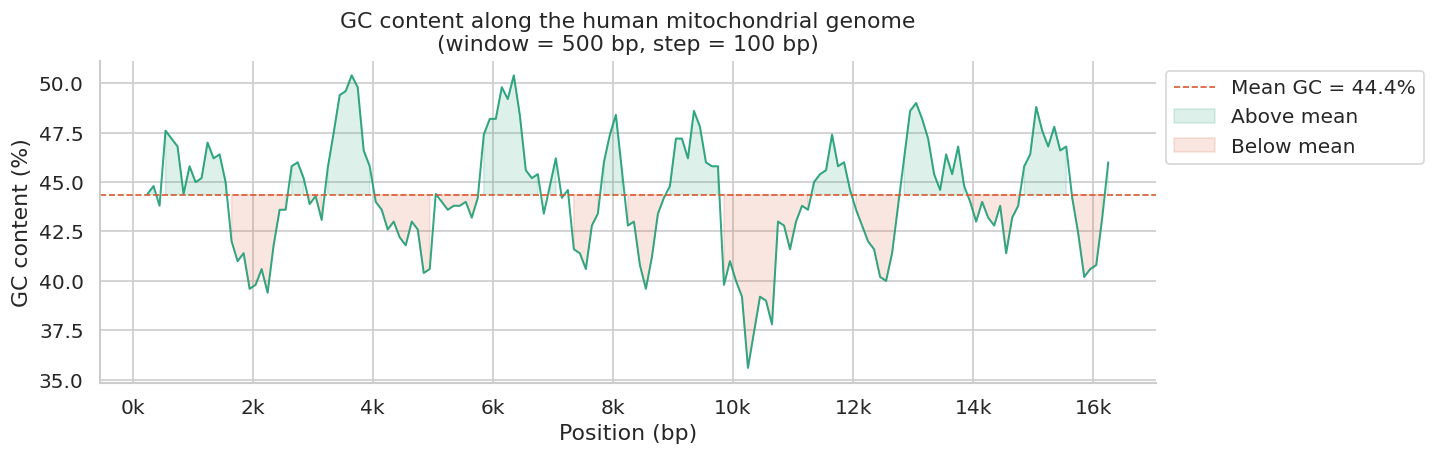

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(positions, gc_values, color='#1D9E75', linewidth=1.2, alpha=0.9)
ax.axhline(gc, color='#D85A30', linestyle='--', linewidth=1, label=f'Mean GC = {gc:.1f}%')
ax.fill_between(positions, gc_values, gc, where=(gc_values > gc),
                alpha=0.15, color='#1D9E75', label='Above mean')
ax.fill_between(positions, gc_values, gc, where=(gc_values < gc),
                alpha=0.15, color='#D85A30', label='Below mean')
ax.set_xlabel('Position (bp)')
ax.set_ylabel('GC content (%)')
ax.set_title('GC content along the human mitochondrial genome\n(window = 500 bp, step = 100 bp)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
sns.despine()
plt.tight_layout()
plt.savefig('gc_sliding_window.png', dpi=150, bbox_inches='tight')
plt.show()

# 4 Trascrizione e Traduzione

Passiamo ora a vedere alcuni metodi di Seq. Estraiamo per comodità i primi 300 nucleotidi dalla sequenza che abbiamo scaricato.

In [14]:
dna=seq[:300]


In [15]:
# Transcription T->U
rna=dna.transcribe()
print(f"DNA: {dna[:60]}...")
print(f"RNA dopo transcription: {rna}...")

# Translation
protein=rna.translate()
print(f"Proteina dopo translation: {protein}")


DNA: GATCACAGGTCTATCACCCTATTAACCACTCACGGGAGCTCTCCATGCATTTGGTATTTT...
RNA dopo transcription: GAUCACAGGUCUAUCACCCUAUUAACCACUCACGGGAGCUCUCCAUGCAUUUGGUAUUUUCGUCUGGGGGGUAUGCACGCGAUAGCAUUGCGAGACGCUGGAGCCGGAGCACCCUAUGUCGCAGUAUCUGUCUUUGAUUCCUGCCUCAUCCUAUUAUUUAUCGCACCUACGUUCAAUAUUACAGGCGAACAUACUUACUAAAGUGUGUUAAUUAAUUAAUGCUUGUAGGACAUAAUAAUAACAAUUGAAUGUCUGCACAGCCACUUUCCACACAGACAUCAUAACAAAAAAUUUCCACCA...
Proteina dopo translation: DHRSITLLTTHGSSPCIWYFRLGGMHAIALRDAGAGAPYVAVSVFDSCLILLFIAPTFNITGEHTY*SVLIN*CL*DIIITIECLHSHFPHRHHNKKFPP


Attenzione! In realtà il mitocondrio utilizza un codice genetico leggermente diverso rispetto al DNA nucleare. Non è un problema perché Biopython fornisce anche questa opzione.

In [16]:
protein_mt = dna.translate(table=2, to_stop=True)
print(f'Protein (mitoch. code)  : {protein_mt}')

Protein (mitoch. code)  : DH


In [17]:
# Se non blocchiamo al primo codone di stop
protein_mt = dna.translate(table=2, to_stop=False)
print(f'Protein (mitoch. code)  : {protein_mt}')

Protein (mitoch. code)  : DH*SITLLTTHGSSPCIWYFRLGGMHAMALRDAGAGAPYVAVSVFDSCLILLFIAPTFNITGEHTY*SVLIN*CL*DMMMTIECLHSHFPH*HHNKKFPP


Ripetiamo ora quello che abbiamo fatto con i nucleotidi e contiamo gli amminoacidi che compaiono nella sequenza.
Usiamo una sequenza un po' più lunga di 3000 basi (1000 aa circa)

In [18]:
from collections import Counter
# Translate si può applicare direttamente alla seq di DNA oppure a quella ottenuta
# con transcribe() in formato RNA
long_protein = seq[:3000].translate(table=2, to_stop=False)

aa_counts=Counter(str(long_protein))
print(aa_counts)

Counter({'T': 100, 'L': 100, 'S': 82, 'P': 78, '*': 71, 'K': 63, 'N': 53, 'A': 51, 'H': 45, 'Q': 45, 'G': 41, 'V': 41, 'M': 35, 'I': 34, 'E': 29, 'R': 28, 'F': 27, 'Y': 26, 'D': 19, 'W': 17, 'C': 15})


Abbiamo come risultato un dizionario con i conteggi per ogni amminoacido. Eliminiamo "*" che indica il segnale di stop.


In [19]:
aa_counts.pop('*', None)

71

In [20]:
### Bonus : Il segnale per indicare i codoni di stop si può customizzare
seq[:3000].translate(table=2, to_stop=False, stop_symbol="@")




Seq('DH@SITLLTTHGSSPCIWYFRLGGMHAMALRDAGAGAPYVAVSVFDSCLILLFI...VGS')

In [21]:
## Bonus 2: Vediamo le differenze tra i codon usage del mitocondrio e il codice standard
from Bio.Data import CodonTable
standard_table = CodonTable.unambiguous_dna_by_name["Standard"]
mito_table = CodonTable.unambiguous_dna_by_name["Vertebrate Mitochondrial"]

## Alternativa usando gli ID

standard_table = CodonTable.unambiguous_dna_by_id[1]
mito_table = CodonTable.unambiguous_dna_by_id[2]

In [22]:
print(standard_table)

Table 1 Standard, SGC0

  |  T      |  C      |  A      |  G      |
--+---------+---------+---------+---------+--
T | TTT F   | TCT S   | TAT Y   | TGT C   | T
T | TTC F   | TCC S   | TAC Y   | TGC C   | C
T | TTA L   | TCA S   | TAA Stop| TGA Stop| A
T | TTG L(s)| TCG S   | TAG Stop| TGG W   | G
--+---------+---------+---------+---------+--
C | CTT L   | CCT P   | CAT H   | CGT R   | T
C | CTC L   | CCC P   | CAC H   | CGC R   | C
C | CTA L   | CCA P   | CAA Q   | CGA R   | A
C | CTG L(s)| CCG P   | CAG Q   | CGG R   | G
--+---------+---------+---------+---------+--
A | ATT I   | ACT T   | AAT N   | AGT S   | T
A | ATC I   | ACC T   | AAC N   | AGC S   | C
A | ATA I   | ACA T   | AAA K   | AGA R   | A
A | ATG M(s)| ACG T   | AAG K   | AGG R   | G
--+---------+---------+---------+---------+--
G | GTT V   | GCT A   | GAT D   | GGT G   | T
G | GTC V   | GCC A   | GAC D   | GGC G   | C
G | GTA V   | GCA A   | GAA E   | GGA G   | A
G | GTG V   | GCG A   | GAG E   | GGG G   | G
--+---------

In [23]:
print(mito_table)

Table 2 Vertebrate Mitochondrial, SGC1

  |  T      |  C      |  A      |  G      |
--+---------+---------+---------+---------+--
T | TTT F   | TCT S   | TAT Y   | TGT C   | T
T | TTC F   | TCC S   | TAC Y   | TGC C   | C
T | TTA L   | TCA S   | TAA Stop| TGA W   | A
T | TTG L   | TCG S   | TAG Stop| TGG W   | G
--+---------+---------+---------+---------+--
C | CTT L   | CCT P   | CAT H   | CGT R   | T
C | CTC L   | CCC P   | CAC H   | CGC R   | C
C | CTA L   | CCA P   | CAA Q   | CGA R   | A
C | CTG L   | CCG P   | CAG Q   | CGG R   | G
--+---------+---------+---------+---------+--
A | ATT I(s)| ACT T   | AAT N   | AGT S   | T
A | ATC I(s)| ACC T   | AAC N   | AGC S   | C
A | ATA M(s)| ACA T   | AAA K   | AGA Stop| A
A | ATG M(s)| ACG T   | AAG K   | AGG Stop| G
--+---------+---------+---------+---------+--
G | GTT V   | GCT A   | GAT D   | GGT G   | T
G | GTC V   | GCC A   | GAC D   | GGC G   | C
G | GTA V   | GCA A   | GAA E   | GGA G   | A
G | GTG V(s)| GCG A   | GAG E   | GGG G   

In [24]:
print(f"Standard stop codon {standard_table.stop_codons}")
print(f"Mito stop codon {mito_table.stop_codons}")

print(f"Standard start codon {standard_table.start_codons}")
print(f"Mito start codon {mito_table.start_codons}")



Standard stop codon ['TAA', 'TAG', 'TGA']
Mito stop codon ['TAA', 'TAG', 'AGA', 'AGG']
Standard start codon ['TTG', 'CTG', 'ATG']
Mito start codon ['ATT', 'ATC', 'ATA', 'ATG', 'GTG']


Ora che abbiamo calcolato gli aa, visualizziamo con un barplot.

In [25]:
aa_df=pd.DataFrame.from_dict(aa_counts,orient='index',columns=['count'])
aa_df=aa_df.sort_values('count',ascending=False)
aa_df.head()

,count
L,100
T,100
S,82
P,78
K,63


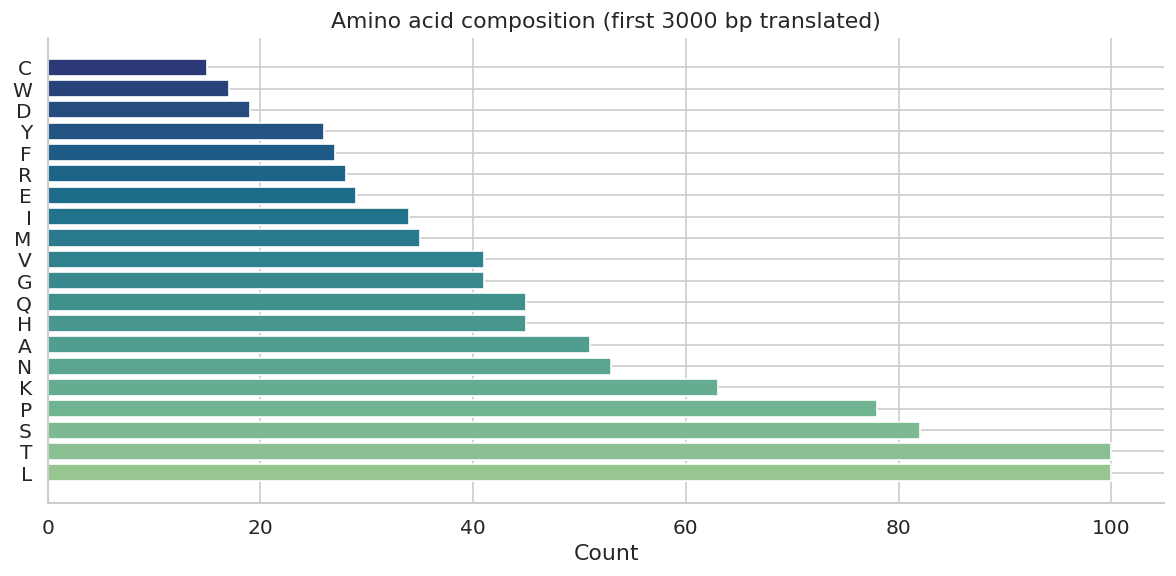

In [26]:
fig,ax=plt.subplots(figsize=(10,5))
colors=sns.color_palette("crest",len(aa_df))
ax.barh(aa_df.index,aa_df["count"],color=colors)
ax.set_xlabel("Count")
ax.set_title("Amino acid composition (first 3000 bp translated)")

sns.despine()
plt.tight_layout()
plt.show()


# Trovare Motivi

La ricerca di motifs consiste nell’identificare brevi sequenze ricorrenti nel DNA, RNA o nelle proteine che possono avere un ruolo biologico specifico.
Questi pattern conservati sono spesso associati a funzioni importanti, come siti di legame per fattori di trascrizione, regioni regolatorie o domini proteici funzionali.

L’analisi dei motifs permette quindi di individuare elementi funzionali nascosti all’interno delle sequenze biologiche e di confrontare regioni conservate tra organismi diversi.


Vediamo prima quali funzioni ci mette a disposizione Biopython e poi definiamo una funzione per ottenere tutte le posizioni di start.

In [28]:
# Proviamo con un motivo semplice
# useremo le funzioni Seq.find() e count()

motif="ATG"
count=seq.count(motif) # Ci restituisce il numero di volte che questo
# motivo compare nella sequenza
print(f"Compare : {count} volta/e")

## .find() ci restituisce la prima posizione della prima occorrenza del motivo
first_pos = seq.find(motif)
print(f"Prima posizione: {first_pos}")

Compare : 162 volta/e
Prima posizione: 44


In [30]:
import re
def find_all_motifs(sequence,motif):
  return [m.start() for m in re.finditer(f'(?={motif})', str(sequence))]


positions_motif=find_all_motifs(seq,"AATAAA") # Segnale di poliadelinazione

print(f'Polyadenylation signal AATAAA found at {len(positions_motif)} positions:')
print(positions_motif[:10], '...' if len(positions_motif) > 10 else '')

Polyadenylation signal AATAAA found at 14 positions:
[835, 965, 1735, 4004, 4570, 4609, 4777, 5404, 8493, 10057] ...


## 6 · Open Reading Frames (ORFs)

Le Open Reading Frames (ORFs) sono regioni del DNA potenzialmente codificanti per proteine.
Un’ORF è definita da una sequenza che inizia con un codone di start (tipicamente ATG) e termina con uno dei codoni di stop (TAA, TAG, TGA), senza interruzioni nel frame di lettura.

L’identificazione delle ORFs è un passaggio fondamentale nell’annotazione genomica, poiché permette di individuare possibili geni e regioni traducibili.


Definiamo una funzione che identifica tutte le possibili ORFs presenti in una sequenza (il nostro genoma mitocondriale, ad esempio) analizzando i sei reading frames:
tre sul filamento forward e tre sul reverse complementare.

La sequenza viene tradotta in proteine utilizzando una specifica tabella genetica, quindi il codice cerca regioni che:

- iniziano con una metionina (M, codone start),
- terminano con un codone di stop (*),
- superano una lunghezza minima definita.

Per ogni ORF trovata vengono salvate informazioni utili come strand, frame di lettura, posizione, lunghezza e sequenza proteica tradotta

In [33]:
def find_orfs(sequence, min_length=100,table=2):
  '''Trova tutte le ORF nei 6 possibili reading frames
  (3 forward + 3 reverse complement).
  Restituisce una lista di dizionari con Frame, start, end, lunghezza e
  sequenza proteica.
  '''

  orfs=[]
  seq_str=str(sequence)
  rc_seq=str(sequence.reverse_complement())
  for strand, nuc in [(+1, seq_str), (-1, rc_seq)]:
        for frame in range(3):
            trans = str(Seq(nuc[frame:]).translate(table=table))
            aa_start = 0
            while True:
                aa_start = trans.find('M', aa_start)
                if aa_start == -1:
                    break
                aa_end = trans.find('*', aa_start)
                if aa_end == -1:
                    aa_end = len(trans)
                length = aa_end - aa_start
                if length >= min_length:
                    orfs.append({
                        'strand': strand,
                        'frame': frame + 1,
                        'aa_start': aa_start,
                        'aa_end': aa_end,
                        'length_aa': length,
                        'protein': trans[aa_start:aa_end]
                    })
                aa_start += 1
  return orfs

In [34]:
orfs = find_orfs(seq, min_length=100)
print(f'Trovate {len(orfs)} ORFs >= 100 aa in the mitochondrial genome')

orf_df = pd.DataFrame(orfs).drop(columns='protein')
orf_df['strand_label'] = orf_df['strand'].map({1: '+', -1: '-'})
print(orf_df.sort_values('length_aa', ascending=False).head(10).to_string(index=False))

Trovate 150 ORFs >= 100 aa in the mitochondrial genome
 strand  frame  aa_start  aa_end  length_aa strand_label
      1      1      4109    4715        606            +
      1      1      4112    4715        603            +
      1      1      4114    4715        601            +
      1      1      4118    4715        597            +
      1      1      4164    4715        551            +
      1      1      4166    4715        549            +
      1      1      4198    4715        517            +
      1      1      4199    4715        516            +
      1      3      1967    2480        513            +
      1      1      4212    4715        503            +


/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


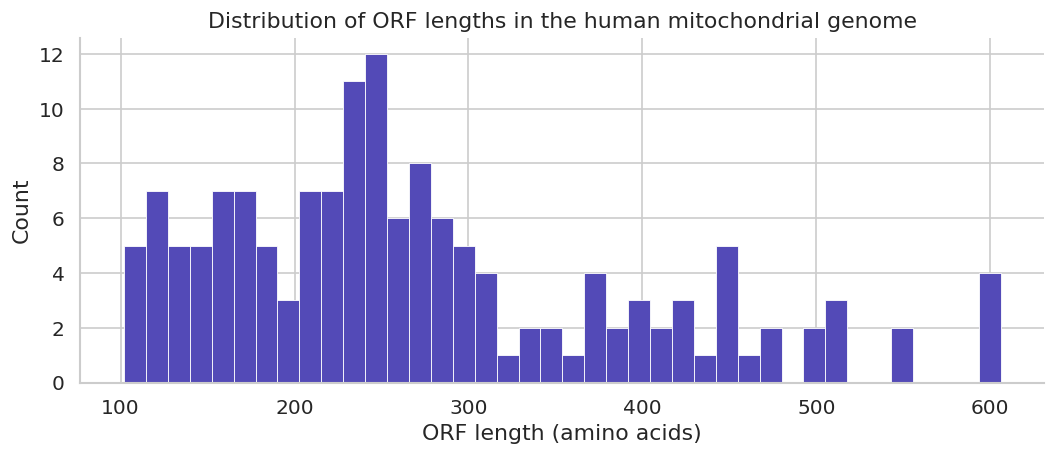

In [35]:
# Distribuzione delle lunghezze delle ORF

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(orf_df['length_aa'], bins=40, color='#534AB7', edgecolor='white', linewidth=0.5)
ax.set_xlabel('ORF length (amino acids)')
ax.set_ylabel('Count')
ax.set_title('Distribution of ORF lengths in the human mitochondrial genome')
sns.despine()
plt.tight_layout()
plt.show()

### Summary finale

In questo notebook abbiamo visto :

| Task | Tool |
|------|------|
| Download sequences from NCBI | `Entrez.efetch()` |
| Parse FASTA files | `SeqIO.read()` / `SeqIO.parse()` |
| Compute GC content | `gc_fraction()` |
| Sliding window GC plot | NumPy + Matplotlib |
| Transcribe and translate | `.transcribe()` / `.translate()` |
| Find motifs | `re` + `Seq.find()` |
| Find ORFs in 6 frames | custom Python function |


## Esercizi

Prova questi esercizi per continuare a fare pratica con Biopython.



### Esercizio 1 — Contenuto G###

 Scarica il genoma di *E.coli*K-12 (`U00096.3`) E M. tuberculosis H37Rv* (`AL123456.3`) da NCBI.

Calcola poi il contenuto GC di ogni genoma.



<details>
<summary>Show solution</summary>

```python
genomes = {'E. coli K-12': 'U00096.3', 'M. tuberculosis H37Rv': 'AL123456.3'}
for name, acc in genomes.items():
    handle = Entrez.efetch(db='nucleotide', id=acc, rettype='fasta', retmode='text')
    rec = SeqIO.read(handle, 'fasta')
    gc = gc_fraction(rec.seq) * 100
    print(f'{name}: {gc:.2f}% GC  ({len(rec.seq):,} bp)')

```
</details>


### Esercizio 2 — Lunghezza delle ORF e distribuzione per strand

Utilizzando la funzione find_orfs() che abbiamo definito nella sezione 6, confronta con un grafico, le lunghezze delle ORFs sul filamento
 **forward (+)** e **reverse (-)** del genoma mitocondriale

<details>
<summary>Show solution</summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (strand_val, strand_name) in zip(axes, [(1, 'Forward (+)'), (-1, 'Reverse (-)')]):
    subset = orf_df[orf_df['strand'] == strand_val]['length_aa']
    ax.hist(subset, bins=30, color='#1D9E75' if strand_val == 1 else '#D85A30',
            edgecolor='white')
    ax.set_title(f'ORF lengths — {strand_name}')
    ax.set_xlabel('Length (aa)')
    ax.set_ylabel('Count')
sns.despine()
plt.tight_layout()
plt.show()
```
</details>

### Esercizio 3
Scegli un organismo a piacere da NCBI.
Cerca l'accession ID da [NCBI](https://www.ncbi.nlm.nih.gov/).

Scarica con Entrez.efetch() e crea:

1) Un grafico con sliding window per calcolare il contenuto di GC
2) Un grafico a barre per il contenuto di nucleotidi
3) Trova le 5 ORFs più lunghe.



<details>
<summary>Show solution</summary>

Non c'è una soluzione unica. Sii creativo/a!⭐